# SI'26 – Week 2 (v2): Data Preprocessing & Exploratory Analysis
**Author: Qandeel Asim**
**Student ID: 2023-BS-AI-037**

---

### What this notebook does
Loads the `labels.csv` your Week 1 (v2) notebook saved to Google Drive
(`image, text, source, split` columns) and validates it thoroughly before any
training happens: confirms every image actually opens, checks text length and
character distribution per source, visualizes samples, and removes any bad rows.

No GPU needed — this is CPU-only data validation.

## Section 0 — Install Packages

In [1]:
!pip install -q pillow pandas matplotlib tqdm
print("Done.")

Done.


## Section 1 — Mount Drive and Load `labels.csv`

Loads from `PROJECT_DIR/labels.csv` — the file your Week 1 (v2) notebook's
Section 9a saved. Image paths inside are stored relative to `PROJECT_DIR`
(e.g. `data/raw/synthetic/urdu_0001.png`), matching how Week 1 copied the whole
`data/` folder there.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Urdu_OCR_Project_v2"  # must match Week 1 (v2)
labels_path = os.path.join(PROJECT_DIR, "labels.csv")

if not os.path.exists(labels_path):
    raise FileNotFoundError(
        f"labels.csv not found at {labels_path}. Run the Week 1 (v2) notebook first, "
        "and make sure it finished Section 9a (saving to Drive)."
    )

df = pd.read_csv(labels_path)
print(f"Loaded {len(df)} rows from labels.csv")
print("Columns:", list(df.columns))
df.head()

Mounted at /content/drive
Loaded 3160 rows from labels.csv
Columns: ['image', 'text', 'source', 'split']


,image,text,source,split
0,data/raw/augmented/urdu_0171_aug1_brightness.png,یہ ایک تاریخی کامیابی تھی,augmented_brightness,train
1,data/raw/augmented/urdu_0395_aug3_blur.png,غزل: دو مصرعوں پر مشتمل مکمل، بامعنی اور جداگا...,augmented_blur,train
2,data/raw/other/utrset_164.jpg,قوّلوں کو کیا نثبت ہے؟,utrset_real,train
3,data/raw/augmented/urdu_0491_aug1_blur.png,ان جن پدوں میں کرو، پانچال، کوشل اور وِدیہ ممل...,augmented_blur,train
4,data/raw/augmented/urdu_0043_aug1_blur.png,اس مطالبے کے تحت تحریک پاکستان وجود میں آئی,augmented_blur,train


## Section 2 — Verify Every Image Actually Opens

Catches any file that's missing, zero-byte, or corrupted — better to find this now
than have training crash partway through an epoch. Image paths are resolved against
`PROJECT_DIR` (so `data/raw/synthetic/urdu_0001.png` becomes
`PROJECT_DIR/data/raw/synthetic/urdu_0001.png`).

In [3]:
from PIL import Image
from tqdm.auto import tqdm

bad_rows = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Checking images"):
    full_path = os.path.join(PROJECT_DIR, row["image"])
    try:
        with Image.open(full_path) as img:
            img.verify()
    except Exception:
        bad_rows.append(idx)

print(f"Bad/unreadable images found: {len(bad_rows)}")
if bad_rows:
    df = df.drop(index=bad_rows).reset_index(drop=True)
    print(f"Dropped {len(bad_rows)} bad rows. Remaining: {len(df)}")
else:
    print("All images opened successfully.")

Checking images:   0%|          | 0/3160 [00:00<?, ?it/s]

Bad/unreadable images found: 0
All images opened successfully.


## Section 3 — Check for Empty, Placeholder, or Duplicate Text Labels

In [4]:
before = len(df)

df["text"] = df["text"].astype(str).str.strip()

# Drop empty text and any unfilled "real photo" placeholders from Section 6a
df = df[df["text"].str.len() > 0]
df = df[df["text"] != "FILL_IN_URDU_TEXT_HERE"]

dup_count = df.duplicated(subset=["image"]).sum()
df = df.drop_duplicates(subset=["image"]).reset_index(drop=True)

print(f"Removed {before - len(df)} rows with empty/placeholder text or duplicate images.")
print(f"Remaining rows: {len(df)}")

Removed 0 rows with empty/placeholder text or duplicate images.
Remaining rows: 3160


## Section 4 — Text Length Distribution (Per Source)

Your dataset now mixes short signboard phrases, medium synthetic sentences, and long
book paragraphs — so length is shown broken down **by source**, not just overall, to
confirm each source still has the length profile it's supposed to.

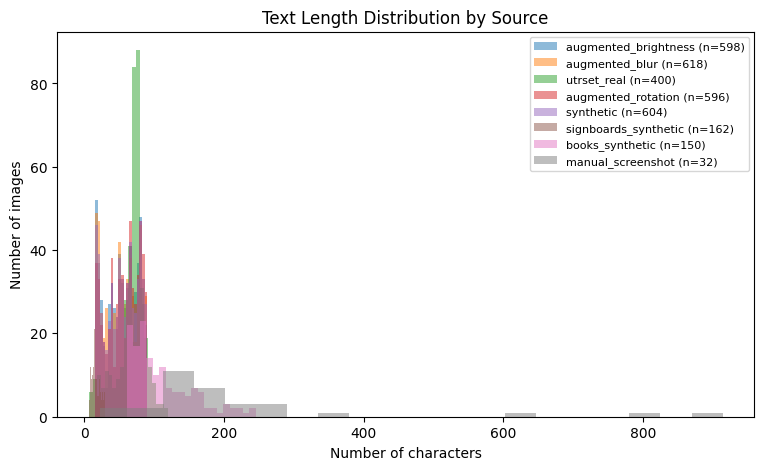

                      count        mean         std   min     25%    50%  \
source                                                                     
augmented_blur        618.0   52.177994   22.734406  15.0   32.00   54.0   
augmented_brightness  598.0   52.677258   22.464963  15.0   34.25   55.0   
augmented_rotation    596.0   55.348993   22.278731  15.0   38.00   58.0   
books_synthetic       150.0  111.720000   43.984457  61.0   79.00   97.0   
manual_screenshot      32.0  223.781250  195.802853  23.0  129.75  162.5   
signboards_synthetic  162.0   16.740741    6.068507   7.0   12.00   15.0   
synthetic             604.0   53.385762   22.539338  15.0   35.00   55.5   
utrset_real           400.0   67.267500   20.759898   6.0   62.00   72.0   

                         75%    max  
source                               
augmented_blur         71.00   90.0  
augmented_brightness   73.00   90.0  
augmented_rotation     75.00   90.0  
books_synthetic       135.75  245.0  
manual_scre

In [5]:
import matplotlib.pyplot as plt

df["text_length"] = df["text"].str.len()

fig, ax = plt.subplots(figsize=(9, 5))
for source in df["source"].unique():
    subset = df[df["source"] == source]["text_length"]
    ax.hist(subset, bins=20, alpha=0.5, label=f"{source} (n={len(subset)})")

ax.set_title("Text Length Distribution by Source")
ax.set_xlabel("Number of characters")
ax.set_ylabel("Number of images")
ax.legend(fontsize=8)
plt.savefig(os.path.join(PROJECT_DIR, "week2_text_length_by_source.png"))
plt.show()

print(df.groupby("source")["text_length"].describe())

## Section 5 — Character Vocabulary Check

Confirms the full range of Urdu characters actually present, and flags anything
unexpected that might have slipped in from Wikipedia text (stray Latin letters,
digits, citation marks, etc.).

In [6]:
all_chars = set()
for t in df["text"]:
    all_chars.update(t)

print(f"Total unique characters in dataset: {len(all_chars)}")

non_urdu_chars = sorted(c for c in all_chars if not ('\u0600' <= c <= '\u06FF') and not c.isspace())
print(f"Non-Urdu-range characters present ({len(non_urdu_chars)}): {non_urdu_chars[:50]}")
print("A handful of digits/punctuation here is normal; a large amount is worth a closer look —")
print("check Section 6 below to see which source they're coming from.")

Total unique characters in dataset: 138
Non-Urdu-range characters present (57): ['!', '"', '%', "'", '(', ')', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', '<', '>', 'B', 'G', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'o', 'p', 'r', 't', 'u', 'y', '~', 'ə', 'ɾ', 'ʃ']
A handful of digits/punctuation here is normal; a large amount is worth a closer look —
check Section 6 below to see which source they're coming from.


## Section 6 — Source Balance Check

In [7]:
print("Images per source:")
print(df["source"].value_counts())
print()
print("Images per split:")
print(df["split"].value_counts())
print()
print(f"Train ratio: {(df['split'] == 'train').mean():.1%}")

Images per source:
source
augmented_blur          618
synthetic               604
augmented_brightness    598
augmented_rotation      596
utrset_real             400
signboards_synthetic    162
books_synthetic         150
manual_screenshot        32
Name: count, dtype: int64

Images per split:
split
train    2528
test      632
Name: count, dtype: int64

Train ratio: 80.0%


## Section 7 — Visual Sample Check (one image per source)

/tmp/ipykernel_1017/315219774.py:19: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1017/315219774.py:19: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_1017/315219774.py:19: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1017/315219774.py:19: UserWarning: Glyph 1731 (\N{ARABIC LETTER TEH MARBUTA GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPytho

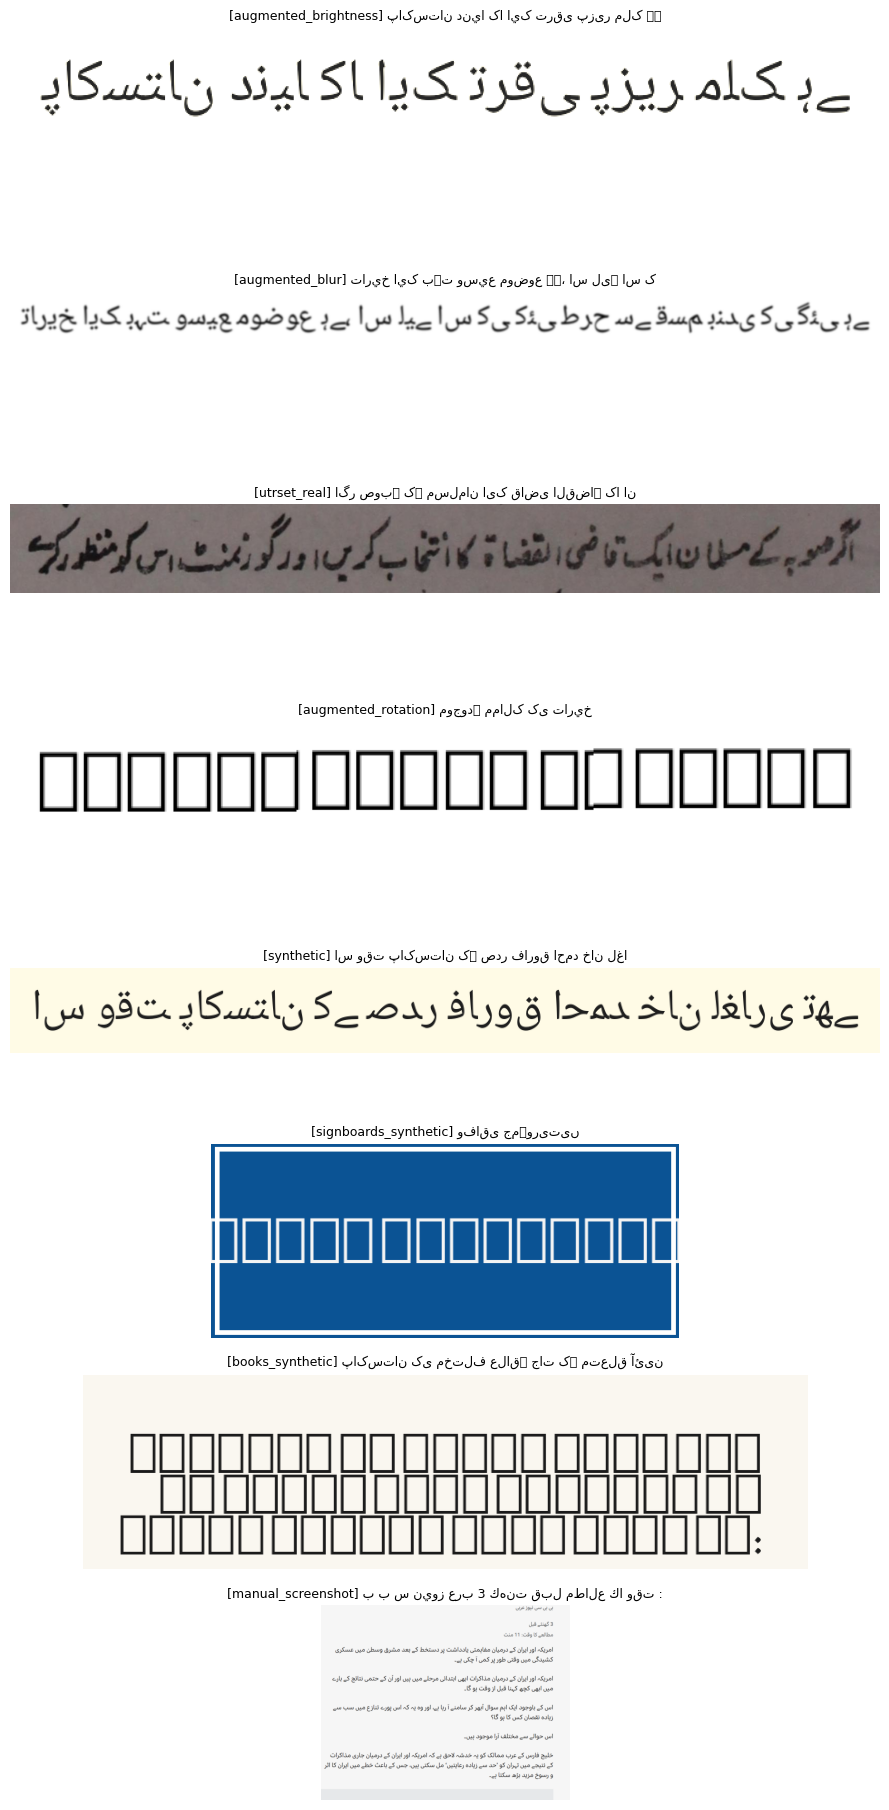

In [8]:
import random

fig_rows = []
for source in df["source"].unique():
    subset = df[df["source"] == source]
    if len(subset) > 0:
        fig_rows.append(subset.sample(1, random_state=1).iloc[0])

fig, axes = plt.subplots(len(fig_rows), 1, figsize=(9, 2.3 * len(fig_rows)))
if len(fig_rows) == 1:
    axes = [axes]

for ax, row in zip(axes, fig_rows):
    img = Image.open(os.path.join(PROJECT_DIR, row["image"]))
    ax.imshow(img)
    ax.set_title(f'[{row["source"]}] {row["text"][:40]}', fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Section 8 — Save the Cleaned `labels.csv`

Overwrites `labels.csv` (both under `PROJECT_DIR` and inside `PROJECT_DIR/data/`) with
the validated, cleaned version — this is the file Week 3 and Week 4 will load.

In [9]:
df_to_save = df.drop(columns=["text_length"])

df_to_save.to_csv(labels_path, index=False)

# Keep the copy inside data/ in sync too, since Week 1 saved both
inner_labels_path = os.path.join(PROJECT_DIR, "data", "labels.csv")
if os.path.exists(os.path.dirname(inner_labels_path)):
    df_to_save.to_csv(inner_labels_path, index=False)

print("Cleaned labels.csv saved to:", labels_path)
print(f"Final dataset size: {len(df_to_save)} images "
      f"({(df_to_save['split']=='train').sum()} train / {(df_to_save['split']=='test').sum()} test)")

Cleaned labels.csv saved to: /content/drive/MyDrive/Urdu_OCR_Project_v2/labels.csv
Final dataset size: 3160 images (2528 train / 632 test)
